First, let's install `pyspark`, which is required to run Spark sessions in Colab.

In [48]:
import pyspark
!pip install pyspark

First, let's load the parquet files for `ride_year=2024` from your Google Drive into a Spark DataFrame.

In [49]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("ColabSparkSession").getOrCreate()
print(spark.version)
spark

4.0.2


In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import math
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

def haversine_km(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0

    # Convert degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(dphi / 2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0)**2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))

    return R * c

# Register as a Spark UDF
haversine_km_udf = udf(haversine_km, DoubleType())

In [51]:
# Define the path to your parquet files
# Assuming 'data' folder is directly under 'MyDrive'
parquet_path = '/content/drive/MyDrive/data/BDA_Project/ride_year=2024'

# Load the parquet files into a Spark DataFrame
ride_df = spark.read.parquet(parquet_path)

print(f"Loaded ride_df with {ride_df.count()} rows and {len(ride_df.columns)} columns.")
ride_df.printSchema()
ride_df.show(5)

Loaded ride_df with 23772650 rows and 18 columns.
root
 |-- end_station_key: string (nullable = true)
 |-- start_station_key: string (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_district: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_district: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- start_time_ms: timestamp (nullable = true)
 |-- end_time_ms: timestamp (nullable = true)
 |-- start_station_name_norm: string (nullable = true)
 |-- end_station_name_norm: string (nullable = true)
 |-- start_coord_key: string (nullable = true)
 |-- end_coord_key: string (nullable = true)
 |-- start_canonical_station_id: string (nullable = true)
 |-- end_canonical_station_id: string (nullable = true)

+--------------------+

In [52]:
!pip install geopandas pyogrio

In [53]:
import requests
import json
from pyspark.sql.functions import col, explode
from pyspark.sql.types import StructType, ArrayType, StringType, LongType, DoubleType, BooleanType

info_url   = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"
status_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_status.json"

# --- Load Station Information ---
# Define schema for station information to ensure correct parsing
station_info_schema = StructType() \
    .add("station_id", StringType()) \
    .add("external_id", StringType()) \
    .add("name", StringType()) \
    .add("short_name", StringType()) \
    .add("lat", DoubleType()) \
    .add("lon", DoubleType()) \
    .add("rental_methods", ArrayType(StringType())) \
    .add("capacity", LongType()) \
    .add("electric_bike_surcharge_waiver", BooleanType()) \
    .add("is_charging", BooleanType()) \
    .add("eightd_has_key_dispenser", BooleanType()) \
    .add("has_kiosk", BooleanType())

# Fetch JSON content using requests
response_info = requests.get(info_url)
response_info.raise_for_status() # Raise an exception for HTTP errors
info_data = json.loads(response_info.text)
stations_info_list = info_data['data']['stations']

# Create Spark DataFrame from the parsed list of dictionaries
station_info_df = spark.createDataFrame(stations_info_list, schema=station_info_schema)

print(f"Loaded station_info_df with {station_info_df.count()} rows and {len(station_info_df.columns)} columns.")
station_info_df.printSchema()
station_info_df.show(5)

# --- Load Station Status ---
# Define schema for station status
vehicle_type_availability_schema = StructType() \
    .add("vehicle_type_id", StringType()) \
    .add("count", LongType())

station_status_schema = StructType() \
    .add("station_id", StringType()) \
    .add("num_bikes_available", LongType()) \
    .add("num_ebikes_available", LongType()) \
    .add("vehicle_types_available", ArrayType(vehicle_type_availability_schema)) \
    .add("num_bikes_disabled", LongType()) \
    .add("num_docks_available", LongType()) \
    .add("num_docks_disabled", LongType()) \
    .add("is_installed", LongType()) \
    .add("is_renting", LongType()) \
    .add("is_returning", LongType()) \
    .add("last_reported", LongType()) \
    .add("eightd_has_available_keys", BooleanType()) \
    .add("is_charging", BooleanType())

# Fetch JSON content using requests
response_status = requests.get(status_url)
response_status.raise_for_status() # Raise an exception for HTTP errors
status_data = json.loads(response_status.text)
stations_status_list = status_data['data']['stations']

# Create Spark DataFrame from the parsed list of dictionaries
station_status_df = spark.createDataFrame(stations_status_list, schema=station_status_schema)

print(f"Loaded station_status_df with {station_status_df.count()} rows and {len(station_status_df.columns)} columns.")
station_status_df.printSchema()
station_status_df.show(5)

Loaded station_info_df with 425 rows and 12 columns.
root
 |-- station_id: string (nullable = true)
 |-- external_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- short_name: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- rental_methods: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- capacity: long (nullable = true)
 |-- electric_bike_surcharge_waiver: boolean (nullable = true)
 |-- is_charging: boolean (nullable = true)
 |-- eightd_has_key_dispenser: boolean (nullable = true)
 |-- has_kiosk: boolean (nullable = true)

+----------+--------------------+--------------------+----------+------------------+------------------+-----------------+--------+------------------------------+-----------+------------------------+---------+
|station_id|         external_id|                name|short_name|               lat|               lon|   rental_methods|capacity|electric_bike_surcharge_waiver|i

In [54]:
import geopandas as gpd
import os

# Define the base path
stm_path = '/content/drive/MyDrive/data/BDA_Project/metro_bus/'

def load_shapefile_to_spark(file_name):
    full_path = os.path.join(stm_path, file_name)
    if os.path.exists(full_path):
        # Read using geopandas (this reads .shp, .dbf, .shx, and .prj automatically)
        gdf = gpd.read_file(full_path)
        # Convert geometry to Well-Known Text (WKT) string to be Spark-compatible
        gdf['geometry'] = gdf['geometry'].apply(lambda x: x.wkt if x is not None else None)
        # Convert all columns to string for a safe initial Spark conversion
        return spark.createDataFrame(gdf.astype(str))
    else:
        print(f"Specific file not found: {full_path}")
        return None

# Load Arrets (Stops) and Lignes (Lines) using the verified filenames from the directory list
stm_arrets_df = load_shapefile_to_spark('stm_arrets_sig.shp')
stm_lignes_df = load_shapefile_to_spark('stm_lignes_sig.shp')

if stm_arrets_df:
    print("\nSTM Arrets (Stops) Metadata:")
    stm_arrets_df.show(5)

if stm_lignes_df:
    print("\nSTM Lignes (Routes) Metadata:")
    stm_lignes_df.show(5)

/tmp/ipykernel_15668/745864123.py:13: UserWarning: Geometry column does not contain geometry.
  gdf['geometry'] = gdf['geometry'].apply(lambda x: x.wkt if x is not None else None)
/tmp/ipykernel_15668/745864123.py:13: UserWarning: Geometry column does not contain geometry.
  gdf['geometry'] = gdf['geometry'].apply(lambda x: x.wkt if x is not None else None)



STM Arrets (Stops) Metadata:
+---------+-------+--------------------+--------------------+----------+--------+--------+-------+----------+--------------------+
|stop_code|stop_id|           stop_name|            stop_url|wheelchair|route_id|loc_type|shelter|service_id|            geometry|
+---------+-------+--------------------+--------------------+----------+--------+--------+-------+----------+--------------------+
|    10118|     43|   Station Angrignon|https://www.stm.i...|         1|       1|       0|    nan|       26M|POINT (296733.669...|
|    10118|  43-01|   Station Angrignon|                None|         1|    None|       2|    nan|       26M|POINT (296677.561...|
|    10120|     42|        Station Monk|https://www.stm.i...|         2|       1|       0|    nan|       26M|POINT (297506.817...|
|    10120|  42-01|Station Monk - Éd...|                None|         2|    None|       2|    nan|       26M|POINT (297515.753...|
|    10120|  42-02|Station Monk - Éd...|             

In [55]:
from pyspark.sql.functions import regexp_extract, col

# Extract longitude and latitude from the POINT (X Y) string
# In many GIS systems, X is Longitude and Y is Latitude
stm_arrets_coords_df = stm_arrets_df.withColumn(
    "longitude",
    regexp_extract(col("geometry"), r"POINT \(([^ ]+) ", 1).cast("double")
).withColumn(
    "latitude",
    regexp_extract(col("geometry"), r" ([^ ]+)\)", 1).cast("double")
)

print("STM Arrets with explicit Latitude and Longitude:")
stm_arrets_coords_df.select("stop_name", "latitude", "longitude").show(5)

STM Arrets with explicit Latitude and Longitude:
+--------------------+-----------------+------------------+
|           stop_name|         latitude|         longitude|
+--------------------+-----------------+------------------+
|   Station Angrignon|5034064.601946615| 296733.6694496935|
|   Station Angrignon|5034048.338108137|  296677.561550543|
|        Station Monk|5034585.077907005| 297506.8170523404|
|Station Monk - Éd...|5034601.625864424|297515.75306016667|
|Station Monk - Éd...|5034568.309883784| 297496.0035076428|
+--------------------+-----------------+------------------+
only showing top 5 rows


In [56]:
import pyproj
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

# Define the transformation: MTM Zone 8 (EPSG:2950) to WGS84 (EPSG:4326)
# Note: STM data for Montreal usually uses MTM Zone 8
projector = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)

@udf(returnType=DoubleType())
def transform_x_to_lon(x, y):
    lon, lat = projector.transform(float(x), float(y))
    return lon

@udf(returnType=DoubleType())
def transform_y_to_lat(x, y):
    lon, lat = projector.transform(float(x), float(y))
    return lat

# Apply transformation to get standard GPS coordinates
stm_arrets_gps_df = stm_arrets_coords_df.withColumn(
    "lon_gps", transform_x_to_lon(col("longitude"), col("latitude"))
).withColumn(
    "lat_gps", transform_y_to_lat(col("longitude"), col("latitude"))
)

print("STM Arrets with GPS Coordinates (Decimal Degrees):")
stm_arrets_gps_df.select("stop_name", "lat_gps", "lon_gps").show(5)

STM Arrets with GPS Coordinates (Decimal Degrees):
+--------------------+-----------------+------------------+
|           stop_name|          lat_gps|           lon_gps|
+--------------------+-----------------+------------------+
|   Station Angrignon| 45.4464751328878|-73.60311947733969|
|   Station Angrignon|45.44632813283605|-73.60383647756994|
|        Station Monk|45.45116713406439|-73.59324347436484|
|Station Monk - Éd...|45.45131613409445|-73.59312947433745|
|Station Monk - Éd...|45.45101613403308|-73.59338147440009|
+--------------------+-----------------+------------------+
only showing top 5 rows


### Context of STM Files

1.  **File Extensions:**
    *   `.shp`: The main file that stores the geometric entities (points for stops, polylines for routes).
    *   `.dbf`: The database file that stores attribute information for each feature (e.g., Stop Name, Route Number).
    *   `.prj`: Stores coordinate system and projection information (crucial for mapping these onto GPS coordinates).
    *   `.shx`: An index file for the geometry.

2.  **Dataset Content:**
    *   **stm_arrets:** This provides the spatial coordinates of every STM bus stop and Metro entrance. You can use this to calculate the distance between your Bixi stations and the nearest transit hub.
    *   **stm_lignes:** This contains the paths of the bus lines. It is useful for understanding transit density in different districts of Montreal.

In [57]:
from pyspark.sql import functions as F
# Load the mapping CSV to resolve canonical_station_id and station_id
mapping_csv_path = '/content/drive/MyDrive/data/BDA_Project/canonical_live_pairs.csv'

spark_mapping_df = spark.read.csv(mapping_csv_path, header=True, inferSchema=True)

print("Loaded spark_mapping_df:")
spark_mapping_df.show(5)

# 1. Combine Station Information and Station Status with unique columns
# Drop 'is_charging' from status feed as it exists in the info feed
status_cols_to_drop = ['lat', 'lon', 'name', 'capacity', 'is_charging']
status_df_clean = station_status_df.drop(*[c for c in status_cols_to_drop if c in station_status_df.columns])

combined_live_data_df = station_info_df.join(
    status_df_clean,
    on="station_id",
    how="inner"
)

# 2. Prepare a perfectly unique resolver
mapping_ids = spark_mapping_df.select("canonical_station_id", "station_id")

spark_live_resolver_df = mapping_ids.join(
    combined_live_data_df,
    on="station_id",
    how="inner"
)

print("Live resolver prepared with a unique schema:")
spark_live_resolver_df.printSchema()
spark_live_resolver_df.show(5)

Loaded spark_mapping_df:
+--------------------+----------+--------------------+--------+------------------+------------------+--------------------+--------------------+
|canonical_station_id|station_id|                name|capacity|               lat|               lon|        match_method|   match_distance_km|
+--------------------+----------+--------------------+--------+------------------+------------------+--------------------+--------------------+
|            STN_0561|         1|Drummond / de Mai...|      27|  45.4996545106653|-73.57633531093597|     exact_coord_key|                 0.0|
|            STN_0346|         3|     Clark / Ontario|      19|45.510493862520995|-73.56692067715812|exact_normalized_...|0.010889656511468624|
|            STN_0146|         8|Ste-Catherine / S...|      43|45.512936177874096|-73.56124520301817|     exact_coord_key|                 0.0|
|            STN_0530|        12|Metcalfe / de Mai...|      23|45.501375027330134| -73.5734578129086|     exact

In [58]:
# 1. Ensure the resolver has a strictly unique set of columns
unique_cols = []
seen_names = set()
for name in spark_live_resolver_df.columns:
    if name not in seen_names:
        unique_cols.append(name)
        seen_names.add(name)

clean_resolver_df = spark_live_resolver_df.select(*unique_cols)

# 2. Helper to create a unique prefix for columns to avoid join ambiguity
def prefix_df_cols(df, prefix):
    return df.select([F.col(c).alias(prefix + c) for c in df.columns])

# Prepare clean, uniquely named resolvers
start_res_clean = prefix_df_cols(clean_resolver_df, "start_live_")
end_res_clean = prefix_df_cols(clean_resolver_df, "end_live_")

# Join rides with START station info
final_ride_df = ride_df.join(
    start_res_clean,
    ride_df.start_canonical_station_id == start_res_clean.start_live_canonical_station_id,
    "left"
).drop("start_live_canonical_station_id")

# Join rides with END station info
final_ride_df = final_ride_df.join(
    end_res_clean,
    final_ride_df.end_canonical_station_id == end_res_clean.end_live_canonical_station_id,
    "left"
).drop("end_live_canonical_station_id")

print(f"Joined ride_df with unique resolver columns. Total columns: {len(final_ride_df.columns)}")

Joined ride_df with unique resolver columns. Total columns: 64


In [59]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Prepare unique Bixi stations with their coordinates
bixi_stations = spark_live_resolver_df.select(
    F.col("canonical_station_id"),
    F.col("lat").alias("bixi_lat"),
    F.col("lon").alias("bixi_lon"),
    F.col("capacity")
).distinct()

# 2. Spatial Join for Transit Proximity
transit_nodes = stm_arrets_gps_df.select(
    F.col("stop_id"),
    F.col("lat_gps").alias("trans_lat"),
    F.col("lon_gps").alias("trans_lon")
)

# Cross join to calculate distances using the haversine_km_udf
station_transit_dist = bixi_stations.crossJoin(transit_nodes) \
    .withColumn("dist_km", haversine_km_udf(F.col("bixi_lat"), F.col("bixi_lon"), F.col("trans_lat"), F.col("trans_lon")))

# Aggregate transit features per Bixi station with 200m, 500m, and 1km thresholds
spatial_features = station_transit_dist.groupBy("canonical_station_id") \
    .agg(
        F.min("dist_km").alias("dist_to_nearest_transit"),
        F.count(F.when(F.col("dist_km") <= 0.2, 1)).alias("stops_within_200m"),
        F.count(F.when(F.col("dist_km") <= 0.5, 1)).alias("stops_within_500m"),
        F.count(F.when(F.col("dist_km") <= 1.0, 1)).alias("stops_within_1km")
    )

print("Spatial transit features (200m, 500m, 1km) engineered successfully.")
spatial_features.show(5)

Spatial transit features (200m, 500m, 1km) engineered successfully.
+--------------------+-----------------------+-----------------+-----------------+----------------+
|canonical_station_id|dist_to_nearest_transit|stops_within_200m|stops_within_500m|stops_within_1km|
+--------------------+-----------------------+-----------------+-----------------+----------------+
|            STN_0922|   0.040252157824285546|                8|               39|             129|
|            STN_0359|    0.19768963128041808|                1|               20|              65|
|            STN_0509|    0.11029319912605738|                4|               32|             150|
|            STN_0435|    0.01984672428308032|                5|               26|              97|
|            STN_0737|     0.0701872475439247|                8|               25|              83|
+--------------------+-----------------------+-----------------+-----------------+----------------+
only showing top 5 rows


In [60]:
from pyspark.ml.evaluation import RegressionEvaluator

# Define the evaluators for each metric
evaluator_rmse = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="r2")

print("Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2")

Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2


In [61]:
# 3. Aggregate Rides into Hourly Net Flow
# Calculate Departures (Out) and Arrivals (In)
out_flow = final_ride_df.groupBy("start_canonical_station_id", F.window("start_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "out_count")

in_flow = final_ride_df.groupBy("end_canonical_station_id", F.window("end_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "in_count")

# Join Flows
hourly_flow = out_flow.join(
    in_flow,
    (out_flow.start_canonical_station_id == in_flow.end_canonical_station_id) & (out_flow.window == in_flow.window),
    "full"
).select(
    F.coalesce(col("start_canonical_station_id"), col("end_canonical_station_id")).alias("station_id"),
    F.coalesce(out_flow.window.start, in_flow.window.start).alias("hour_timestamp"),
    F.coalesce(col("out_count"), F.lit(0)).alias("departures"),
    F.coalesce(col("in_count"), F.lit(0)).alias("arrivals")
)

hourly_flow = hourly_flow.withColumn("net_flow", col("arrivals") - col("departures"))

In [62]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Join Spatial Transit Features onto final_ride_df
final_ride_features_df = final_ride_df.join(
    spatial_features.alias("spatial"),
    final_ride_df.start_canonical_station_id == F.col("spatial.canonical_station_id"),
    "left"
).drop(F.col("spatial.canonical_station_id"))

# 2. Temporal Feature Engineering
final_ride_features_df = final_ride_features_df.withColumn("hour", F.hour("start_time_ms")) \
    .withColumn("day_of_week", F.dayofweek("start_time_ms")) \
    .withColumn("month", F.month("start_time_ms")) \
    .withColumn("is_weekend", F.when(F.dayofweek("start_time_ms").isin(1, 7), 1).otherwise(0))

# 3. Congestion Ratio
final_ride_features_df = final_ride_features_df.withColumn(
    "start_congestion_ratio",
    F.lit(1) / F.col("start_live_capacity")
)

# 4. Hourly Net Flow Aggregation & Lagged Features
out_flow = final_ride_features_df.groupBy("start_canonical_station_id", F.window("start_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "out_count")

in_flow = final_ride_features_df.groupBy("end_canonical_station_id", F.window("end_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "in_count")

hourly_flow_df = out_flow.join(
    in_flow,
    (out_flow.start_canonical_station_id == in_flow.end_canonical_station_id) & (out_flow.window == in_flow.window),
    "full"
).select(
    F.coalesce(F.col("start_canonical_station_id"), F.col("end_canonical_station_id")).alias("canonical_station_id"),
    F.coalesce(out_flow.window.start, in_flow.window.start).alias("hour_timestamp"),
    F.coalesce(F.col("out_count"), F.lit(0)).alias("departures"),
    F.coalesce(F.col("in_count"), F.lit(0)).alias("arrivals")
)

hourly_flow_df = hourly_flow_df.withColumn("net_flow", F.col("arrivals") - F.col("departures"))

# 5. Apply Lags
w_station = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")
lags = [1, 2, 6, 12, 24, 48, 168]
for l in lags:
    hourly_flow_df = hourly_flow_df.withColumn(f"net_flow_lag{l}", F.lag("net_flow", l).over(w_station))

print("Features and lags engineered successfully.")
hourly_flow_df.show(5)

Features and lags engineered successfully.
+--------------------+-------------------+----------+--------+--------+-------------+-------------+-------------+--------------+--------------+--------------+---------------+
|canonical_station_id|     hour_timestamp|departures|arrivals|net_flow|net_flow_lag1|net_flow_lag2|net_flow_lag6|net_flow_lag12|net_flow_lag24|net_flow_lag48|net_flow_lag168|
+--------------------+-------------------+----------+--------+--------+-------------+-------------+-------------+--------------+--------------+--------------+---------------+
|                NULL|2024-04-03 20:00:00|         0|       1|       1|         NULL|         NULL|         NULL|          NULL|          NULL|          NULL|           NULL|
|                NULL|2024-04-03 21:00:00|         0|       1|       1|            1|         NULL|         NULL|          NULL|          NULL|          NULL|           NULL|
|                NULL|2024-04-04 00:00:00|         1|       0|      -1|           

### 1. Data Preparation for Regression
We will join the spatial and temporal features back to our hourly flow aggregation, then split the data by time.

In [63]:
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Update Trip-Level features to safely handle zero capacity
final_ride_features_safe_df = final_ride_features_df.withColumn(
    "start_congestion_ratio",
    F.when(F.col("start_live_capacity") > 0, F.lit(1) / F.col("start_live_capacity")).otherwise(0)
)

# 2. Aggregate Trip-Level Congestion to Hourly level
hourly_congestion = final_ride_features_safe_df.groupBy(
    "start_canonical_station_id",
    F.window("start_time_ms", "1 hour")
).agg(F.avg("start_congestion_ratio").alias("avg_congestion_ratio")) \
.select(
    F.col("start_canonical_station_id").alias("canonical_station_id"),
    F.col("window.start").alias("hour_timestamp"),
    "avg_congestion_ratio"
)

# 3. Engineer Volume Features (Daily and Monthly Rides)
daily_rides = final_ride_features_safe_df.groupBy(
    "start_canonical_station_id",
    F.date_trunc("day", "start_time_ms").alias("date")
).count().withColumnRenamed("count", "daily_ride_count")

monthly_rides = final_ride_features_safe_df.groupBy(
    "start_canonical_station_id",
    F.date_trunc("month", "start_time_ms").alias("month_date")
).count().withColumnRenamed("count", "monthly_ride_count")

# 4. Join everything into the Model DataFrame
model_df = hourly_flow_df.join(
    hourly_congestion,
    on=["canonical_station_id", "hour_timestamp"],
    how="left"
).join(
    clean_resolver_df.select(F.col("canonical_station_id"), F.col("capacity")),
    on="canonical_station_id",
    how="inner"
).join(
    spatial_features,
    on="canonical_station_id",
    how="inner"
)

model_df = model_df.withColumn("date_link", F.date_trunc("day", "hour_timestamp")) \
    .withColumn("month_link", F.date_trunc("month", "hour_timestamp"))

model_df = model_df.join(daily_rides, (model_df.canonical_station_id == daily_rides.start_canonical_station_id) & (model_df.date_link == daily_rides.date), "left") \
    .drop("start_canonical_station_id", "date") \
    .join(monthly_rides, (model_df.canonical_station_id == monthly_rides.start_canonical_station_id) & (model_df.month_link == monthly_rides.month_date), "left") \
    .drop("start_canonical_station_id", "month_date", "date_link", "month_link")

# 5. Temporal features and temporal splits
model_df = model_df.withColumn("hour", F.hour("hour_timestamp")) \
    .withColumn("day_of_week", F.dayofweek("hour_timestamp")) \
    .withColumn("month", F.month("hour_timestamp")) \
    .withColumn("is_weekend", F.when(F.dayofweek("hour_timestamp").isin(1, 7), 1).otherwise(0)) \
    .fillna(0, subset=["avg_congestion_ratio", "daily_ride_count", "monthly_ride_count"])

model_df = model_df.dropna()

train_df = model_df.filter(
    (F.year("hour_timestamp") == 2024) |
    ((F.year("hour_timestamp") == 2025) & (F.month("hour_timestamp") <= 6))
)

test_df = model_df.filter((F.year("hour_timestamp") == 2025) & (F.month("hour_timestamp") > 6))

print(f"Data ready. Processing features for training...")

Data ready. Processing features for training...


In [65]:
# Re-run training with safe data and new volume features
feature_cols = [
    "dist_to_nearest_transit", "stops_within_200m", "stops_within_500m", "stops_within_1km",
    "hour", "day_of_week", "month", "is_weekend",
    "avg_congestion_ratio", "capacity",
    "daily_ride_count", "monthly_ride_count",
    "net_flow_lag1", "net_flow_lag2", "net_flow_lag6",
    "net_flow_lag12", "net_flow_lag24", "net_flow_lag48", "net_flow_lag168"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_data = assembler.transform(train_df)

gbt = GBTRegressor(featuresCol="features", labelCol="net_flow", maxIter=10)
gbt_model = gbt.fit(train_data)

# Display Importances
importances = gbt_model.featureImportances
importance_list = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

print("Feature Importances (Safe Calculation & New Features):")
for feature, score in importance_list:
    print(f"{feature:25}: {score:.4f}")

Feature Importances (Safe Calculation & New Features):
net_flow_lag1            : 0.2604
avg_congestion_ratio     : 0.2369
hour                     : 0.1366
net_flow_lag2            : 0.0764
net_flow_lag24           : 0.0677
stops_within_1km         : 0.0469
net_flow_lag168          : 0.0339
net_flow_lag48           : 0.0322
daily_ride_count         : 0.0300
net_flow_lag12           : 0.0281
month                    : 0.0197
stops_within_500m        : 0.0101
capacity                 : 0.0085
net_flow_lag6            : 0.0081
monthly_ride_count       : 0.0018
stops_within_200m        : 0.0017
dist_to_nearest_transit  : 0.0009
is_weekend               : 0.0002
day_of_week              : 0.0000


### 1. Model Evaluation on Test Set
We apply the trained GBT model to the `test_df` and calculate standard regression metrics.

In [66]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F
import datetime

# 1. Verify the date range
date_range = model_df.select(F.min("hour_timestamp"), F.max("hour_timestamp")).collect()
print(f"Data range: {date_range[0][0]} to {date_range[0][1]}")

# 2. Adjust split: Use 80% for training and 20% for testing based on time
# Cast timestamp to double to calculate quantile
model_with_ts_numeric = model_df.withColumn("ts_double", F.col("hour_timestamp").cast("double"))
split_date_numeric = model_with_ts_numeric.approxQuantile("ts_double", [0.8], 0.01)[0]
split_timestamp = datetime.datetime.fromtimestamp(split_date_numeric)
print(f"Using split date: {split_timestamp}")

train_df_adj = model_df.filter(F.col("hour_timestamp") < split_timestamp)
test_df_adj = model_df.filter(F.col("hour_timestamp") >= split_timestamp)

# 3. Re-train and Evaluate
train_data_adj = assembler.transform(train_df_adj)
gbt_model_adj = gbt.fit(train_data_adj)
test_data_adj = assembler.transform(test_df_adj)
predictions = gbt_model_adj.transform(test_data_adj)



Data range: 2024-01-09 16:00:00 to 2026-01-05 04:00:00
Using split date: 2025-08-24 01:00:00


In [67]:
# 4. Metrics
rmse = evaluator_rmse.evaluate(predictions)
mae  = evaluator_mae.evaluate(predictions)
r2   = evaluator_r2.evaluate(predictions)

print(f"\nEvaluation Metrics on Adjusted Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

print("\nSample Predictions:")
predictions.select("canonical_station_id", "hour_timestamp", "net_flow", "prediction").show(5)


Evaluation Metrics on Adjusted Test Set:
RMSE: 6.1192
MAE : 3.6696
R2  : 0.5213

Sample Predictions:
+--------------------+-------------------+--------+------------------+
|canonical_station_id|     hour_timestamp|net_flow|        prediction|
+--------------------+-------------------+--------+------------------+
|            STN_0001|2025-08-24 01:00:00|      39|23.762951221944515|
|            STN_0001|2025-08-24 02:00:00|      13|18.893725242799064|
|            STN_0001|2025-08-24 05:00:00|      36|11.796625538106175|
|            STN_0001|2025-08-24 09:00:00|       6|6.6787929824994565|
|            STN_0001|2025-08-24 11:00:00|      13|12.252656389671715|
+--------------------+-------------------+--------+------------------+
only showing top 5 rows


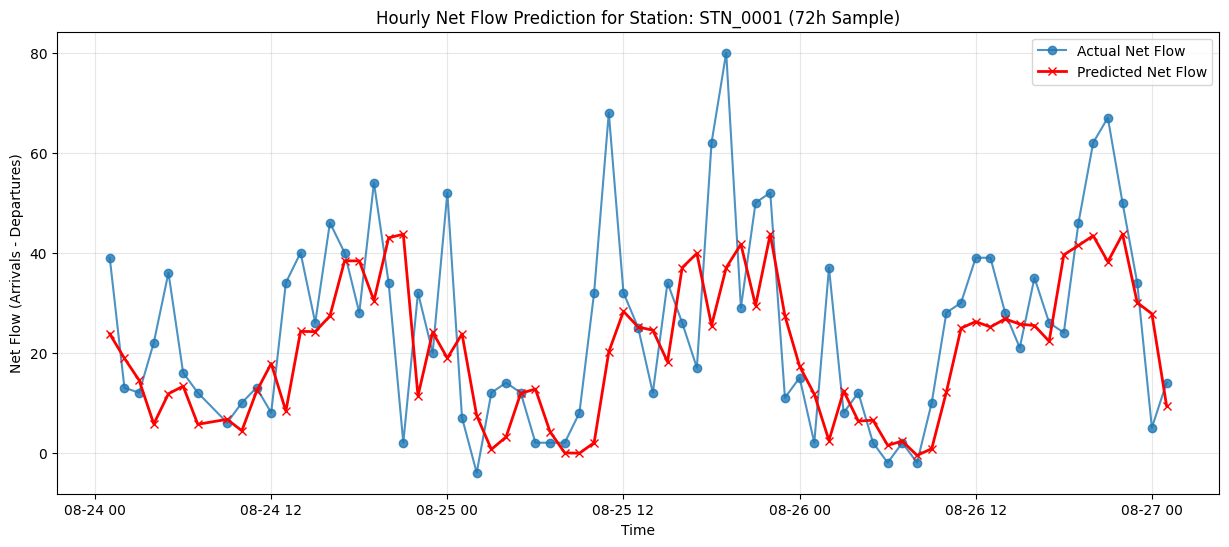

Metrics for STN_0001:
Average Actual Net Flow: 22.03
Average Predicted Net Flow: 17.01


In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter predictions for the specific station STN_0001
specific_stn_id = "STN_0001"
stn_0001_preds = predictions.filter(F.col("canonical_station_id") == specific_stn_id).sort("hour_timestamp").toPandas()

# 2. Convert to Pandas datetime
stn_0001_preds['hour_timestamp'] = pd.to_datetime(stn_0001_preds['hour_timestamp'])

# 3. Plot a 72-hour sample to see the hourly prediction quality
sample_stn = stn_0001_preds.head(72) # First 3 days of the test period

plt.figure(figsize=(15, 6))
plt.plot(sample_stn['hour_timestamp'], sample_stn['net_flow'], label='Actual Net Flow', marker='o', alpha=0.8)
plt.plot(sample_stn['hour_timestamp'], sample_stn['prediction'], label='Predicted Net Flow', marker='x', color='red', linewidth=2)
plt.title(f'Hourly Net Flow Prediction for Station: {specific_stn_id} (72h Sample)')
plt.xlabel('Time')
plt.ylabel('Net Flow (Arrivals - Departures)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Show summary metrics for this specific station
print(f"Metrics for {specific_stn_id}:")
print(f"Average Actual Net Flow: {stn_0001_preds['net_flow'].mean():.2f}")
print(f"Average Predicted Net Flow: {stn_0001_preds['prediction'].mean():.2f}")

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert the Spark predictions to a Pandas DataFrame for easier plotting
# We'll take a representative subset or aggregate to keep it performant
pred_df = predictions.select("hour_timestamp", "net_flow", "prediction").toPandas()
pred_df['hour_timestamp'] = pd.to_datetime(pred_df['hour_timestamp'])
pred_df = pred_df.sort_values('hour_timestamp')

/tmp/ipykernel_15668/2543785034.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_perf = pred_df.set_index('hour_timestamp').resample('M').mean()


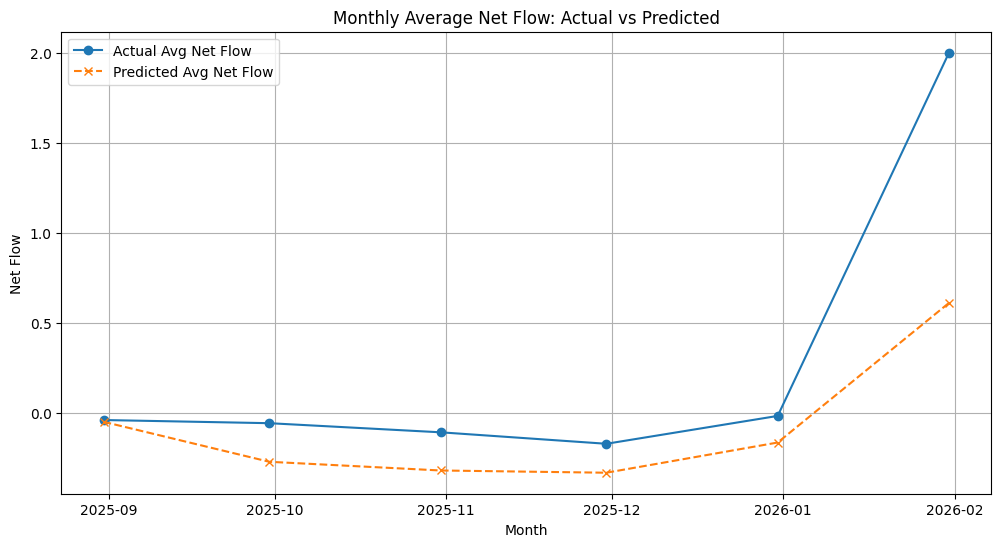

In [70]:
# 1. Monthly View
monthly_perf = pred_df.set_index('hour_timestamp').resample('M').mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_perf.index, monthly_perf['net_flow'], label='Actual Avg Net Flow', marker='o')
plt.plot(monthly_perf.index, monthly_perf['prediction'], label='Predicted Avg Net Flow', linestyle='--', marker='x')
plt.title('Monthly Average Net Flow: Actual vs Predicted')
plt.xlabel('Month')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True)
plt.show()

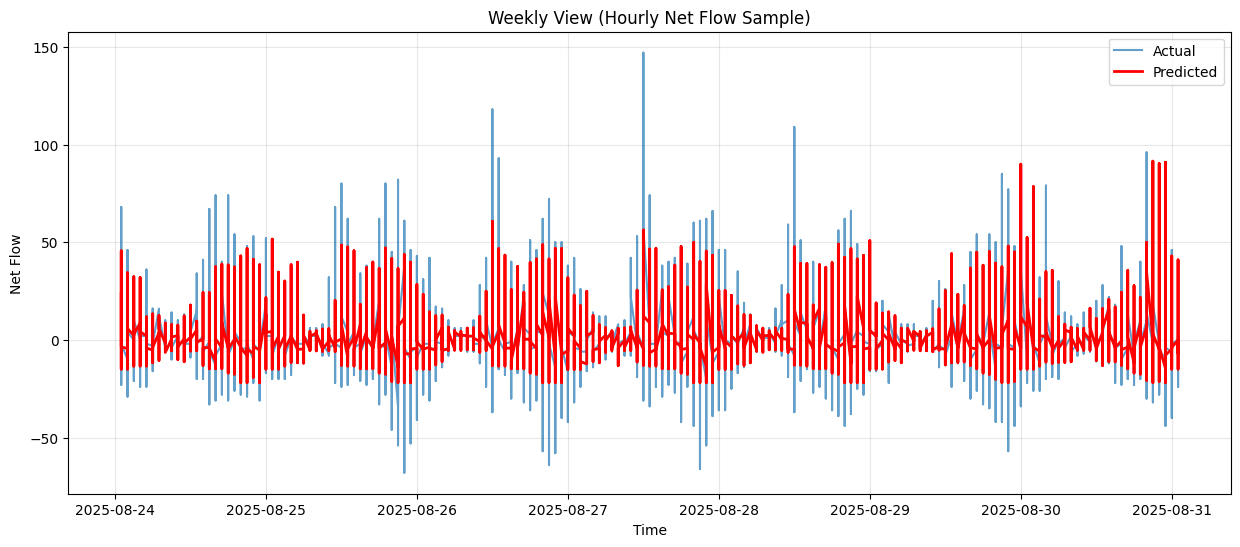

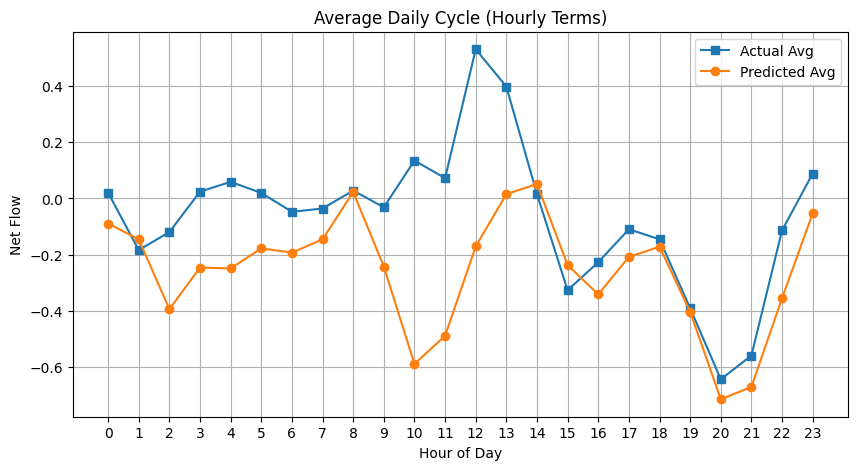

In [71]:
# 2. Weekly Sample (First week of the test set)
start_date = pred_df['hour_timestamp'].min()
end_date = start_date + pd.Timedelta(days=7)
weekly_sample = pred_df[(pred_df['hour_timestamp'] >= start_date) & (pred_df['hour_timestamp'] <= end_date)]

plt.figure(figsize=(15, 6))
plt.plot(weekly_sample['hour_timestamp'], weekly_sample['net_flow'], label='Actual', alpha=0.7)
plt.plot(weekly_sample['hour_timestamp'], weekly_sample['prediction'], label='Predicted', color='red', linewidth=2)
plt.title('Weekly View (Hourly Net Flow Sample)')
plt.xlabel('Time')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Hourly Day View (Average across all days in test set)
pred_df['hour_of_day'] = pred_df['hour_timestamp'].dt.hour
daily_cycle = pred_df.groupby('hour_of_day')[['net_flow', 'prediction']].mean()

plt.figure(figsize=(10, 5))
plt.plot(daily_cycle.index, daily_cycle['net_flow'], label='Actual Avg', marker='s')
plt.plot(daily_cycle.index, daily_cycle['prediction'], label='Predicted Avg', marker='o')
plt.title('Average Daily Cycle (Hourly Terms)')
plt.xlabel('Hour of Day')
plt.ylabel('Net Flow')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.show()

In [1]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F

# 1. Define window partitioned by station and ordered by time
window_spec = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")

# 2. Calculate cumulative net flow (Predicted Inventory Change)
# We use the 'prediction' column from our GBT model to forecast future state
predictions_with_inventory = predictions.withColumn(
    "cumulative_net_flow_forecast",
    F.sum("prediction").over(window_spec)
)

# 3. Define a starting point (Initial Bikes)
# In a real scenario, this would be the current 'num_bikes_available'
# For this simulation, let's assume stations start at 50% capacity
predictions_with_inventory = predictions_with_inventory.withColumn(
    "predicted_bikes_available",
    (F.col("capacity") * 0.5) + F.col("cumulative_net_flow_forecast")
)

# 4. Create Refill Flag (e.g., if predicted bikes drop below 10% of capacity)
predictions_with_inventory = predictions_with_inventory.withColumn(
    "refill_required_flag",
    F.when(F.col("predicted_bikes_available") < (F.col("capacity") * 0.1), 1).otherwise(0)
)

print("Cumulative flow and refill flags calculated.")
predictions_with_inventory.select(
    "canonical_station_id",
    "hour_timestamp",
    "prediction",
    "predicted_bikes_available",
    "refill_required_flag"
).show(10)

PySparkRuntimeError: [SESSION_OR_CONTEXT_NOT_EXISTS] SparkContext or SparkSession should be created first.